# 自动微分

---

## 练习2.5.1

为什么计算二阶导数比一阶导数的开销要更大？

### &emsp;解答

&emsp;&emsp;在 PyTorch 中计算一阶导数和二阶导数都是通过自动微分机制实现的，但是计算二阶导数的开销通常要比计算一阶导数更大，原因如下：

1. 计算图的构建：在计算一阶导数时，PyTorch 只需要构建一次计算图，然后根据需要进行反向传播即可。而在计算二阶导数时，需要构建两次计算图，第一次是计算一阶导数，第二次是计算一阶导数的导数，也就是二阶导数。因此，计算二阶导数需要更多的计算图构建操作。
2. 内存占用：计算一阶导数时，PyTorch 只需要保留一阶导数的梯度值，而计算二阶导数时需要保留一阶导数和二阶导数的梯度值，这会占用更多的内存。
3. 计算量增加：计算二阶导数需要对一阶导数进行额外的计算，这增加了计算量和计算时间。

因此，计算二阶导数的开销通常要比计算一阶导数更大。

---

## 练习2.5.2

在运行反向传播函数之后，立即再次运行它，看看会发生什么。

### &emsp;解答

In [7]:
import numpy as np
import torch
import pypto

device = "npu:0"

# PyPTO kernel: y = x^2
@pypto.frontend.jit
def square_kernel(
    x: pypto.Tensor([...], pypto.DT_FP32),
    out: pypto.Tensor([...], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(1, 4)
    out[:] = x * x

# 把 PyPTO kernel 包装成 torch.autograd.Function
class PyPTOSquare(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        out = torch.empty_like(x)
        square_kernel(x, out)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        return grad_output * 2.0 * x

def pypto_square(x):
    return PyPTOSquare.apply(x)

# 第一次 backward：成功（1D x，与教程范例一致；不要 reshape 避免破坏 leaf）
x = torch.arange(4.0, dtype=torch.float32, device=device, requires_grad=True)
y = pypto_square(x)
print("x      =", x)
y.sum().backward()
print("x.grad =", x.grad)

# 第二次 backward：报错（计算图被释放）
try:
    y.sum().backward()
    print("x.grad =", x.grad)
except RuntimeError as e:
    print("RuntimeError:", e)

x      = tensor([0., 1., 2., 3.], device='npu:0', requires_grad=True)
x.grad = tensor([0., 2., 4., 6.], device='npu:0')
RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.


根据上述运行结果，在运行反向传播函数之后，立即再次运行它，会报错，提示“尝试第二次反向传播（或者在释放保存的张量后直接访问它们）。调用.backward()或autograd.grad()时，将释放图中保存的中间值。如果需要第二次执行反向传播，或者在反向传播调用后需要访问保存的张量，请指定retain_graph=True。”

In [ ]:
# 用 retain_graph=True 修复
x2 = torch.arange(4.0, dtype=torch.float32, device=device, requires_grad=True)
y2 = pypto_square(x2)

y2.sum().backward(retain_graph=True)
grad_after_first = x2.grad.detach().clone()
print("x2.grad (1st) =", grad_after_first)
y2.sum().backward()
grad_after_second = x2.grad.detach().clone()
print("x2.grad (2nd) =", grad_after_second)

# 互验：PyPTO 前向/梯度 vs torch 参考
x_ref = torch.arange(4.0, dtype=torch.float32, device=device)
expected_once = (2 * x_ref).cpu().numpy()
expected_twice = (4 * x_ref).cpu().numpy()

print("第一次梯度一致性 :", np.allclose(grad_after_first.cpu().numpy(), expected_once, rtol=1e-3, atol=1e-3))
print("第二次梯度一致性 :", np.allclose(grad_after_second.cpu().numpy(), expected_twice, rtol=1e-3, atol=1e-3))

x2.grad (1st) = tensor([0., 2., 4., 6.], device='npu:0')
x2.grad (2nd) = tensor([ 0.,  4.,  8., 12.], device='npu:0')
第一次梯度一致性 : True
第二次梯度一致性 : True


---

## 练习2.5.3

在控制流的例子中，我们计算`d`关于`a`的导数，如果将变量`a`更改为随机向量或矩阵，会发生什么？

### &emsp;解答

&emsp;&emsp;PyPTO 不内建自动微分，且其控制流 `pypto.cond` / `pypto.loop` 必须是**静态有界**的——循环边界在编译时确定，无法表达 `while b.norm() < 1000` 这种**数据相关**循环（迭代次数取决于输入值）。因此本练习保留 torch 实现，重点放在观察 torch autograd 对非标量 `backward()` 的报错行为。

In [9]:
import torch

def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c
a = torch.randn(size=(1, 3), requires_grad=True)
d = f(a)
try:
    d.backward()
except Exception as e:
    print(e)

grad can be implicitly created only for scalar outputs


根据上述执行结果，如果将变量`a`更改为随机向量或矩阵，会报错，因为 PyTorch 只能对标量结果求梯度，可以将代码进行以下修改：

In [10]:
try:
    d.backward(torch.ones_like(d))
except Exception as e:
    print(e)
print(a.grad)

tensor([[204800., 204800., 204800.]])


---

## 练习2.5.4

重新设计一个求控制流梯度的例子，运行并分析结果。

### &emsp;解答

&emsp;&emsp;同上：PyPTO 静态控制流无法表达 `while b.norm(1) < 1000`，本练习保留 torch 实现，重点观察把 `a` 改为标量 + `c.sum()` 后 `backward()` 能正常运行的原因。

In [11]:
import torch

def f(a):
    b = a * 2
    while b.norm(1) < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c.sum()
a = torch.randn(size=(), requires_grad=True)
d = f(a)
print(a)
d.backward()
print(a.grad)

tensor(-0.1669, requires_grad=True)
tensor(819200.)


---

## 练习2.5.5

使$f(x)=\sin(x)$，绘制$f(x)$和$\displaystyle \frac{df(x)}{dx}$的图像，其中后者不使用$f'(x)=\cos(x)$。

### &emsp;解答

&emsp;&emsp;用 PyPTO 写两个 kernel：`sin_kernel`（前向）与 `cos_kernel`（backward 中手写 sin 的导数 $\frac{dy}{dx}=\cos(x)$）。把 `sin_kernel` 包成 `torch.autograd.Function` 接入 PyTorch 自动微分，最后与 `torch.sin` + `torch.autograd` 路径互验并画图。

前向 sin(x) 一致性 : True
梯度 df/dx 一致性 : True


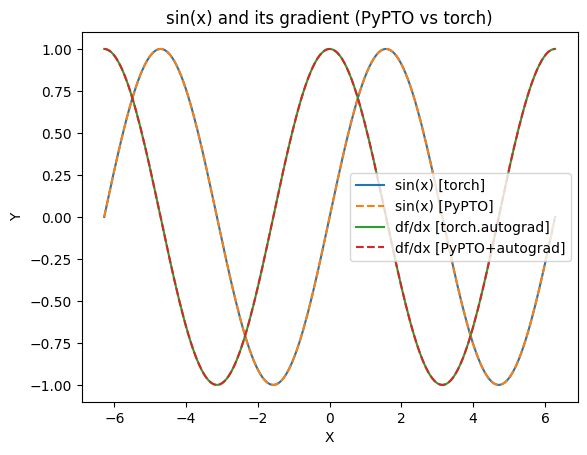

In [12]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pypto

device = "npu:0"
N = 200

# Kernel 1: y = sin(x)（1D 输入，不 reshape 以保留 leaf）
@pypto.frontend.jit
def sin_kernel(
    x: pypto.Tensor([N], pypto.DT_FP32),
    out: pypto.Tensor([N], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(N)
    out[:] = pypto.sin(x)

# Kernel 2: y = cos(x) —— 在 autograd backward 中用于手写 sin 的导数
@pypto.frontend.jit
def cos_kernel(
    x: pypto.Tensor([N], pypto.DT_FP32),
    out: pypto.Tensor([N], pypto.DT_FP32),
):
    pypto.set_vec_tile_shapes(N)
    out[:] = pypto.cos(x)

# 把 sin kernel 包成 torch.autograd.Function
class PyPTOSin(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x):
        ctx.save_for_backward(x)
        out = torch.empty_like(x)
        sin_kernel(x, out)
        return out

    @staticmethod
    def backward(ctx, grad_output):
        (x,) = ctx.saved_tensors
        cos_out = torch.empty_like(x)
        cos_kernel(x, cos_out)
        return grad_output * cos_out

def pypto_sin(x):
    return PyPTOSin.apply(x)

# ===== PyTorch 参考 =====
x_torch = torch.linspace(-2 * torch.pi, 2 * torch.pi, N, device=device, requires_grad=True)
y_torch = torch.sin(x_torch)
y_torch.sum().backward()
grad_torch = x_torch.grad.detach().cpu().numpy()

# ===== PyPTO 路径 =====
x_pypto = torch.linspace(-2 * torch.pi, 2 * torch.pi, N, device=device, requires_grad=True)
y_pypto = pypto_sin(x_pypto)
y_pypto.sum().backward()
grad_pypto = x_pypto.grad.detach().cpu().numpy()

# ===== 互验 =====
print("前向 sin(x) 一致性 :", np.allclose(y_pypto.detach().cpu().numpy(), y_torch.detach().cpu().numpy(), rtol=1e-3, atol=1e-3))
print("梯度 df/dx 一致性 :", np.allclose(grad_pypto, grad_torch, rtol=1e-3, atol=1e-3))

# ===== 绘图 =====
x_np = x_torch.detach().cpu().numpy()
plt.plot(x_np, y_torch.detach().cpu().numpy(), label='sin(x) [torch]')
plt.plot(x_np, y_pypto.detach().cpu().numpy(), '--', label='sin(x) [PyPTO]')
plt.plot(x_np, grad_torch, label="df/dx [torch.autograd]")
plt.plot(x_np, grad_pypto, '--', label="df/dx [PyPTO+autograd]")
plt.legend()
plt.xlabel("X")
plt.ylabel("Y")
plt.title("sin(x) and its gradient (PyPTO vs torch)")
plt.show()